In [1]:
import pandas as pd
import numpy as np
import ta
import matplotlib.pyplot as plt

In [2]:
spy = pd.read_csv("../data/raw/SPY.csv", index_col="Date", parse_dates=True)
spy.head()

,Close,High,Low,Open,Volume
Date,,,,,
2014-01-02,148.198456,149.130172,147.841974,149.057247,119636900
2014-01-03,148.174133,148.749368,147.963491,148.449592,81390600
2014-01-06,147.744797,148.717013,147.517947,148.660306,108028200
2014-01-07,148.652176,148.903330,148.222780,148.336205,86144200
2014-01-08,148.684570,148.935725,148.174152,148.627852,96582300


In [3]:
# RSI - Relative Strength Index (14 day)
spy["RSI"] = ta.momentum.RSIIndicator(spy["Close"], window=14).rsi()

spy[["Close", "RSI"]].tail(10)

,Close,RSI
Date,,
2023-12-15,455.586395,77.812662
2023-12-18,458.149139,79.662957
2023-12-19,460.935089,81.471879
2023-12-20,454.547791,66.801346
2023-12-21,458.857727,70.642765
2023-12-22,459.779907,71.405174
2023-12-26,461.721344,72.995207
2023-12-27,462.556152,73.673108
2023-12-28,462.730865,73.821223


In [4]:
# MACD - Moving Average Convergence Divergence
macd = ta.trend.MACD(spy["Close"], window_slow=26, window_fast=12, window_sign=9)

spy["MACD"] = macd.macd()
spy["MACD_Signal"] = macd.macd_signal()
spy["MACD_Hist"] = macd.macd_diff()

spy[["Close", "MACD", "MACD_Signal", "MACD_Hist"]].tail(10)

,Close,MACD,MACD_Signal,MACD_Hist
Date,,,,
2023-12-15,455.586395,7.290375,6.508337,0.782038
2023-12-18,458.149139,7.589629,6.724595,0.865034
2023-12-19,460.935089,7.959837,6.971644,0.988193
2023-12-20,454.547791,7.649647,7.107244,0.542403
2023-12-21,458.857727,7.663258,7.218447,0.444811
2023-12-22,459.779907,7.660156,7.306789,0.353367
2023-12-26,461.721344,7.725302,7.390492,0.334811
2023-12-27,462.556152,7.754900,7.463373,0.291527
2023-12-28,462.730865,7.703651,7.511429,0.192222


In [5]:
# Bollinger Bands
bb = ta.volatility.BollingerBands(spy["Close"], window=20, window_dev=2)

spy["BB_Upper"] = bb.bollinger_hband()
spy["BB_Middle"] = bb.bollinger_mavg()
spy["BB_Lower"] = bb.bollinger_lband()

spy[["Close", "BB_Upper", "BB_Middle", "BB_Lower"]].tail(10)

,Close,BB_Upper,BB_Middle,BB_Lower
Date,,,,
2023-12-15,455.586395,455.182006,443.492554,431.803102
2023-12-18,458.149139,457.370367,444.608891,431.847415
2023-12-19,460.935089,460.033083,445.696790,431.360496
2023-12-20,454.547791,460.912861,446.513181,432.113500
2023-12-21,458.857727,462.477913,447.460472,432.443031
2023-12-22,459.779907,463.978779,448.440338,432.901897
2023-12-26,461.721344,465.536618,449.556912,433.577206
2023-12-27,462.556152,466.973445,450.693477,434.413509
2023-12-28,462.730865,468.091183,451.854245,435.617307


In [6]:
# Simple Moving Averages
spy["SMA_20"] = ta.trend.SMAIndicator(spy["Close"], window=20).sma_indicator()
spy["SMA_50"] = ta.trend.SMAIndicator(spy["Close"], window=50).sma_indicator()
spy["SMA_200"] = ta.trend.SMAIndicator(spy["Close"], window=200).sma_indicator()

# Exponential Moving Averages
spy["EMA_12"] = ta.trend.EMAIndicator(spy["Close"], window=12).ema_indicator()
spy["EMA_26"] = ta.trend.EMAIndicator(spy["Close"], window=26).ema_indicator()

spy[["Close", "SMA_20", "SMA_50", "SMA_200", "EMA_12", "EMA_26"]].tail(10)

,Close,SMA_20,SMA_50,SMA_200,EMA_12,EMA_26
Date,,,,,,
2023-12-15,455.586395,443.492554,427.365434,414.898164,447.628143,440.337768
2023-12-18,458.149139,444.608891,428.222858,415.256509,449.246758,441.657129
2023-12-19,460.935089,445.696790,429.082829,415.627446,451.044963,443.085126
2023-12-20,454.547791,446.513181,429.771547,415.996088,451.583859,443.934212
2023-12-21,458.857727,447.460472,430.512045,416.383173,452.702916,445.039658
2023-12-22,459.779907,448.440338,431.322422,416.810055,453.791684,446.131528
2023-12-26,461.721344,449.556912,432.213393,417.273657,455.011631,447.286329
2023-12-27,462.556152,450.693477,433.033275,417.744063,456.172327,448.417427
2023-12-28,462.730865,451.854245,433.857037,418.184887,457.181333,449.477682


In [7]:
# ATR - Average True Range (volatility)
spy["ATR"] = ta.volatility.AverageTrueRange(
    spy["High"], spy["Low"], spy["Close"], window=14
).average_true_range()

# OBV - On Balance Volume
spy["OBV"] = ta.volume.OnBalanceVolumeIndicator(
    spy["Close"], spy["Volume"]
).on_balance_volume()

spy[["Close", "ATR", "OBV"]].tail(10)

,Close,ATR,OBV
Date,,,
2023-12-15,455.586395,3.896681,2611893000
2023-12-18,458.149139,3.871431,2682268300
2023-12-19,460.935089,3.799445,2738030100
2023-12-20,454.547791,4.088297,2635109100
2023-12-21,458.857727,4.123543,2721776600
2023-12-22,459.779907,4.084163,2788937000
2023-12-26,461.721344,3.995594,2844324000
2023-12-27,462.556152,3.832920,2912324300
2023-12-28,462.730865,3.648583,2989482400


In [8]:
# See all columns
spy.columns.tolist()

['Close',
 'High',
 'Low',
 'Open',
 'Volume',
 'RSI',
 'MACD',
 'MACD_Signal',
 'MACD_Hist',
 'BB_Upper',
 'BB_Middle',
 'BB_Lower',
 'SMA_20',
 'SMA_50',
 'SMA_200',
 'EMA_12',
 'EMA_26',
 'ATR',
 'OBV']

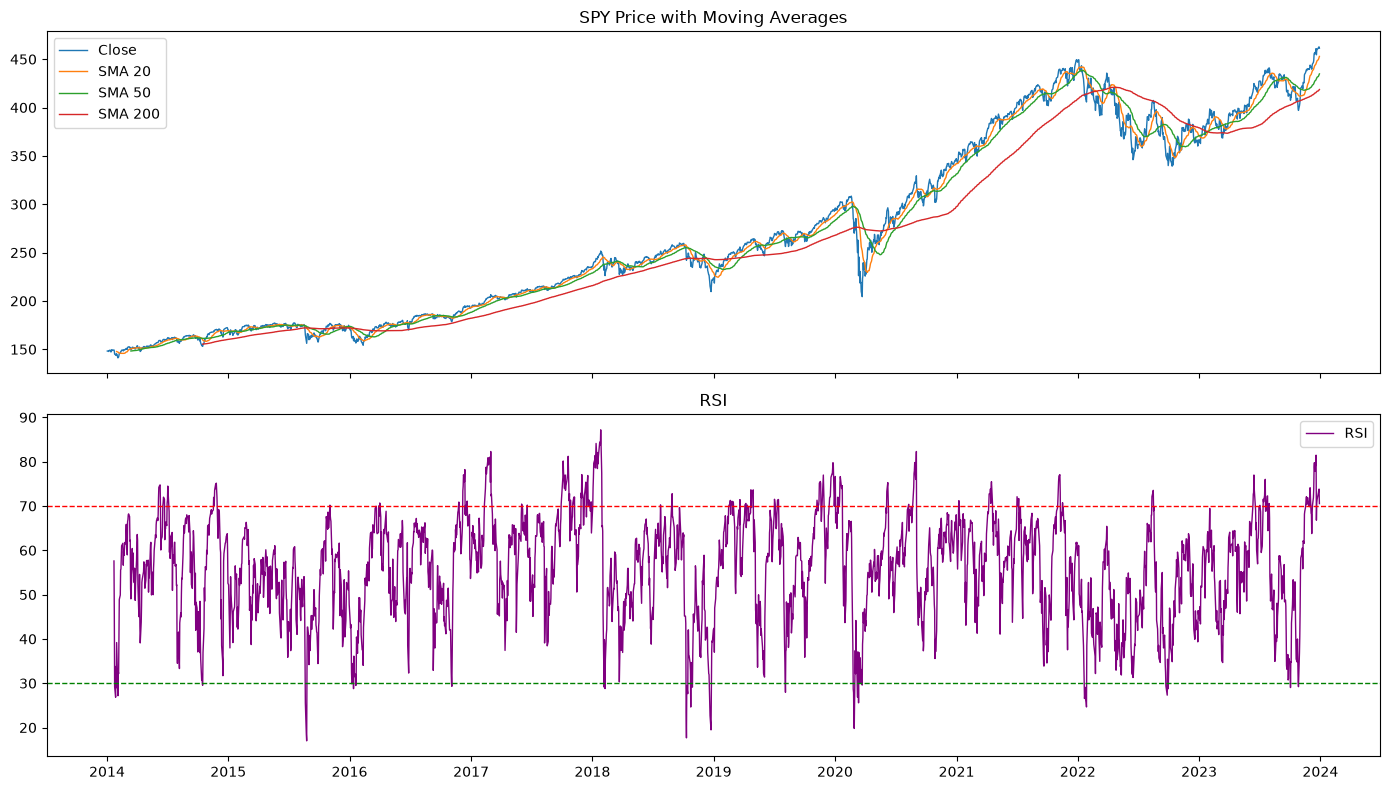

In [9]:
# Plot Close price with SMA overlays
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top chart - Price with moving averages
ax1.plot(spy.index, spy["Close"], label="Close", linewidth=1)
ax1.plot(spy.index, spy["SMA_20"], label="SMA 20", linewidth=1)
ax1.plot(spy.index, spy["SMA_50"], label="SMA 50", linewidth=1)
ax1.plot(spy.index, spy["SMA_200"], label="SMA 200", linewidth=1)
ax1.set_title("SPY Price with Moving Averages")
ax1.legend()

# Bottom chart - RSI
ax2.plot(spy.index, spy["RSI"], label="RSI", color="purple", linewidth=1)
ax2.axhline(70, color="red", linestyle="--", linewidth=1)
ax2.axhline(30, color="green", linestyle="--", linewidth=1)
ax2.set_title("RSI")
ax2.legend()

plt.tight_layout()
plt.show()

In [10]:
# Stochastic Oscillator
stoch = ta.momentum.StochasticOscillator(
    spy["High"], spy["Low"], spy["Close"], window=14, smooth_window=3
)
spy["Stoch_K"] = stoch.stoch()
spy["Stoch_D"] = stoch.stoch_signal()

# Williams %R
spy["Williams_R"] = ta.momentum.WilliamsRIndicator(
    spy["High"], spy["Low"], spy["Close"], lbp=14
).williams_r()

# Rate of Change
spy["ROC"] = ta.momentum.ROCIndicator(spy["Close"], window=12).roc()

spy[["Stoch_K", "Stoch_D", "Williams_R", "ROC"]].tail(10)

,Stoch_K,Stoch_D,Williams_R,ROC
Date,,,,
2023-12-15,87.753043,92.608303,-12.246957,3.656502
2023-12-18,95.295849,91.537785,-4.704151,3.830752
2023-12-19,99.658202,94.235698,-0.341798,3.847785
2023-12-20,67.384710,87.446253,-32.615290,2.949177
2023-12-21,86.338985,84.460632,-13.661015,3.945797
2023-12-22,90.394557,81.372750,-9.605443,4.576118
2023-12-26,96.141832,90.958458,-3.858168,4.222433
2023-12-27,99.324731,95.287040,-0.675269,3.963911
2023-12-28,96.123778,97.196781,-3.876222,3.600230


In [11]:
print(f"Total columns: {len(spy.columns)}")
print(spy.columns.tolist())

Total columns: 23
['Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'ATR', 'OBV', 'Stoch_K', 'Stoch_D', 'Williams_R', 'ROC']


In [13]:
# Drop rows with NaN values
spy_clean = spy.dropna()

print(f"Rows before dropping NaN: {len(spy)}")
print(f"Rows after dropping NaN: {len(spy_clean)}")

# Save to CSV instead
import os
os.makedirs("../data/processed", exist_ok=True)
spy_clean.to_csv("../data/processed/SPY_features.csv")

print("Saved to data/processed/SPY_features.csv!")

Rows before dropping NaN: 2516
Rows after dropping NaN: 2317
Saved to data/processed/SPY_features.csv!


In [14]:
# Verify the saved file loads correctly
spy_final = pd.read_csv("../data/processed/SPY_features.csv", index_col="Date", parse_dates=True)

print(f"Shape: {spy_final.shape}")
print(f"Columns: {spy_final.columns.tolist()}")
print(f"Date range: {spy_final.index[0]} to {spy_final.index[-1]}")

Shape: (2317, 23)
Columns: ['Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'ATR', 'OBV', 'Stoch_K', 'Stoch_D', 'Williams_R', 'ROC']
Date range: 2014-10-16 00:00:00 to 2023-12-29 00:00:00
